# 02 — Image Pairing
Sample 100 images from the House Rooms dataset and pair them to tabular rows via **feature-based matching** on `OverallQual`.

## 2.1 — Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from image_utils import (
    collect_image_paths, sample_images,
    build_qual_buckets, create_pairing_df,
    visualize_pairing_samples, visualize_qual_distribution
)

np.random.seed(42)
print("Setup complete.")

Setup complete.


## 2.2 — Load OverallQual Values

In [2]:
qual_vals = np.load("../data/processed/qual_values.npy")
print(f"Total rows      : {len(qual_vals)}")
print(f"OverallQual min : {qual_vals.min()}   max : {qual_vals.max()}")

Total rows      : 1460
OverallQual min : 1   max : 10


## 2.3 — Collect Image Paths
> **Download**: [Kaggle – House Rooms Image Dataset](https://www.kaggle.com/datasets/robinreni/house-rooms-image-dataset)  
> Extract to `../data/raw/images/` (any sub-folder structure is fine).

In [3]:
IMAGE_DIR = "../data/raw/images"

all_paths = collect_image_paths(IMAGE_DIR, recursive=True)
print(f"Total images found : {len(all_paths)}")

[collect_image_paths] Found 5250 images in '../data/raw/images'
Total images found : 5250


## 2.4 — Sample 100 Images

In [4]:
N_IMAGES = 100
sampled_paths = sample_images(all_paths, n=N_IMAGES, seed=42)
print(f"Sampled {len(sampled_paths)} images")
print("First 3 paths:")
for p in sampled_paths[:3]:
    print(" ", p)

[sample_images] Sampled 100 images (seed=42)
Sampled 100 images
First 3 paths:
  ../data/raw/images\Bathroom\bath_1091.jpg
  ../data/raw/images\Bathroom\bath_185.jpg
  ../data/raw/images\Bathroom\bath_262.jpg


## 2.5 — Build Quality Buckets
Split the 100 images into 10 buckets (one per OverallQual level, 1–10).  
Each tabular row is assigned an image from its matching quality bucket.

In [5]:
buckets = build_qual_buckets(sampled_paths, n_buckets=10)

print("Images per bucket:")
for q, imgs in buckets.items():
    print(f"  OverallQual={q:2d}  →  {len(imgs)} images")

[build_qual_buckets] Bucket sizes: {1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10, 9: 10, 10: 10}
Images per bucket:
  OverallQual= 1  →  10 images
  OverallQual= 2  →  10 images
  OverallQual= 3  →  10 images
  OverallQual= 4  →  10 images
  OverallQual= 5  →  10 images
  OverallQual= 6  →  10 images
  OverallQual= 7  →  10 images
  OverallQual= 8  →  10 images
  OverallQual= 9  →  10 images
  OverallQual=10  →  10 images


## 2.6 — Create Full Pairing DataFrame

In [6]:
df_pair = create_pairing_df(qual_vals, all_paths, n_images=N_IMAGES)

print(f"Pairing DataFrame shape: {df_pair.shape}")
df_pair.head(10)

[sample_images] Sampled 100 images (seed=42)
[build_qual_buckets] Bucket sizes: {1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10, 9: 10, 10: 10}
[pair_images_to_rows] Paired 1460 rows to images
Pairing DataFrame shape: (1460, 3)


,row_idx,OverallQual,image_path
0,0,7,../data/raw/images\Dinning\din_754.jpg
1,1,6,../data/raw/images\Dinning\din_151.jpg
2,2,7,../data/raw/images\Dinning\din_880.jpg
3,3,7,../data/raw/images\Dinning\din_915.jpg
4,4,8,../data/raw/images\Kitchen\kitchen_1327.jpg
5,5,5,../data/raw/images\Dinning\din_1022.jpg
6,6,8,../data/raw/images\Kitchen\kitchen_294.jpg
7,7,7,../data/raw/images\Dinning\din_940.jpg
8,8,7,../data/raw/images\Dinning\din_970.jpg
9,9,5,../data/raw/images\Dinning\din_1060.jpg


## 2.7 — Visualise Sample Pairings

[visualize_pairing_samples] Saved figure to '../outputs/plots/sample_pairings.png'


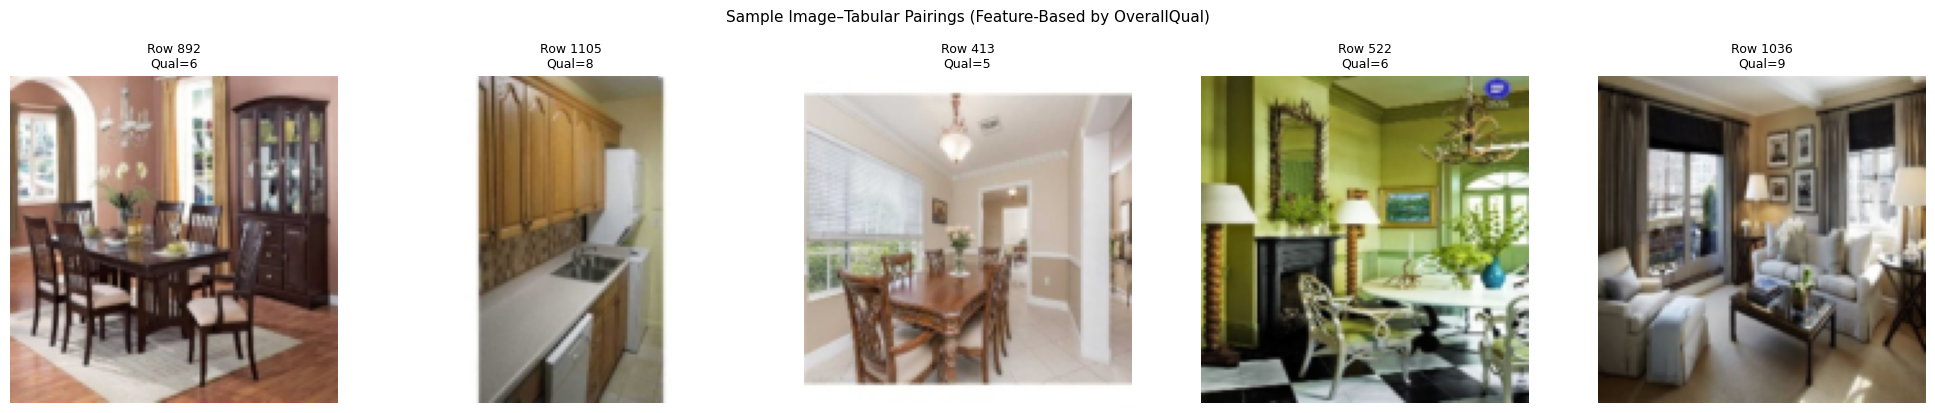

In [7]:
visualize_pairing_samples(
    df_pair,
    n_samples=5,
    save_path="../outputs/plots/sample_pairings.png"
)

## 2.8 — Quality Distribution

d:\AiMl_Internship\phase 2\task 3\src\image_utils.py:203: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Blues_d")


[visualize_qual_distribution] Saved figure to '../outputs/plots/qual_distribution.png'


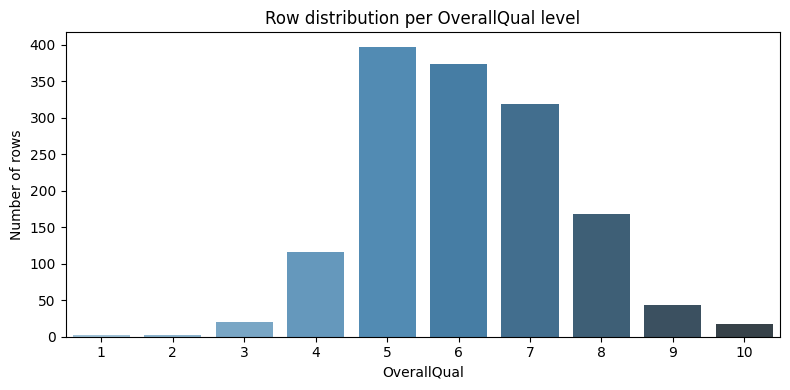

In [8]:
visualize_qual_distribution(
    df_pair,
    save_path="../outputs/plots/qual_distribution.png"
)

## 2.9 — Save Pairing CSV

In [9]:
out_path = "../data/processed/pairing.csv"
df_pair.to_csv(out_path, index=False)
print(f"Pairing CSV saved → '{out_path}'")
df_pair.info()

Pairing CSV saved → '../data/processed/pairing.csv'
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   row_idx      1460 non-null   int64
 1   OverallQual  1460 non-null   int64
 2   image_path   1460 non-null   str  
dtypes: int64(2), str(1)
memory usage: 90.8 KB
